# Hyperparameter Effect Analysis

This notebook analyzes the effect of different hyperparameters on model performance by aggregating runs across different hyperparameter values and visualizing the results.

## Overview
- Load results from W&B hyperparameter search
- Aggregate performance metrics across folds for each hyperparameter value
- Visualize the effect of each hyperparameter on model performance
- Generate summary statistics and plots


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils_table_generator import load_results_dataframe
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


## Configuration

Set your W&B project details and analysis parameters here.


In [2]:
# W&B Configuration
wandb_username = "lcornelis"  # Change this to your W&B username
wandb_project = "Proteo_new_variable_stratified_filtered"  # Change this to your W&B project name
metric = "mse"  # Metric to analyze (e.g., "mse", "mae", etc.)
original_units = True  # Set to True if you want to convert back to original units
csv_filename = f"{wandb_project}_{wandb_username}_hyperparameter_analysis.csv"
force_load = False  # Set to True to force reload from W&B
save_csv = True  # Set to True to save results to CSV

# Model Filter Configuration
# Set to None to analyze all models, or specify a model name to filter by
# Example: filter_model = "ModelName" or filter_model = None
filter_model = "gcn"  # Change this to filter by a specific model

# Analysis Configuration
min_runs_per_hyperparam = 5  # Minimum number of runs required for a hyperparameter value to be included
exclude_hyperparams = [  # Hyperparameters to exclude from analysis
    'dataset', 'model', 'fold', 'val_mae', 'test_mae', 'checkpoint'
]

print(f"Configuration:")
print(f"- W&B Project: {wandb_username}/{wandb_project}")
print(f"- Metric: {metric}")
print(f"- Original units: {original_units}")
print(f"- Min runs per hyperparam: {min_runs_per_hyperparam}")
if filter_model is not None:
    print(f"- Filtering by model: {filter_model}")
else:
    print(f"- Analyzing all models")


Configuration:
- W&B Project: lcornelis/Proteo_new_variable_stratified_filtered
- Metric: mse
- Original units: True
- Min runs per hyperparam: 5
- Filtering by model: gcn


## Load Data

Load the results from W&B or from a previously saved CSV file.


In [3]:
# Load the data
df = load_results_dataframe(
    wandb_username=wandb_username,
    wandb_project=wandb_project,
    original_units=original_units,
    metric=metric,
    csv_filename=csv_filename,
    force_load=force_load,
    save_csv=save_csv
)

print(f"Loaded data shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Filter by model if specified
if filter_model is not None:
    if 'model' in df.columns:
        available_models = df['model'].unique()
        print(f"\nAvailable models: {list(available_models)}")
        
        if filter_model in available_models:
            df = df[df['model'] == filter_model].copy()
            print(f"\nFiltered to model '{filter_model}'")
            print(f"Filtered data shape: {df.shape}")
        else:
            print(f"\nWARNING: Model '{filter_model}' not found in data!")
            print(f"Available models are: {list(available_models)}")
            print("Continuing with all models...")
    else:
        print("\nWARNING: 'model' column not found in dataframe. Cannot filter by model.")
else:
    if 'model' in df.columns:
        available_models = df['model'].unique()
        print(f"\nAvailable models: {list(available_models)}")

print(f"\nFirst few rows:")
df.head()


▶ After building df, df.shape = (42157, 186)
Loaded data shape: (42157, 186)
Columns: ['dataset', 'model', 'fold', 'val_mae', 'test_mae', 'checkpoint', 'loss._target_', 'loss.dataset_loss.task', 'loss.dataset_loss.loss_type', 'loss.modules_losses.readout', 'loss.modules_losses.backbone', 'loss.modules_losses.feature_encoder', 'seed', 'tags', 'test', 'model.compile', 'model.readout.fc_act', 'model.readout.fc_dim', 'model.readout._target_', 'model.readout.num_nodes', 'model.readout.fc_dropout', 'model.readout.hidden_dim', 'model.readout.task_level', 'model.readout.which_layer', 'model.readout.fc_input_dim', 'model.readout.out_channels', 'model.readout.pooling_type', 'model.readout.readout_name', 'model.readout.use_features', 'model.readout.graph_encoder_dim', 'model.readout.feature_encoder_dim', 'model.readout.num_cell_dimensions', 'model.readout.use_feature_encoder', 'model._target_', 'model.backbone._target_', 'model.model_domain', 'model.feature_encoder._target_', 'model.feature_encod

,dataset,model,fold,val_mae,test_mae,checkpoint,loss._target_,loss.dataset_loss.task,loss.dataset_loss.loss_type,loss.modules_losses.readout,...,model.backbone.local_conv_type,transforms.CombinedPSEs.encodings,transforms.CombinedPSEs.parameters.RWSE.max_pe_dim,transforms.CombinedPSEs.parameters.RWSE.concat_to_x,transforms.CombinedPSEs.parameters.LapPE.max_pe_dim,transforms.CombinedPSEs.parameters.LapPE.concat_to_x,transforms.CombinedPSEs.parameters.LapPE.include_first,transforms.CombinedPSEs.parameters.LapPE.include_eigenvalues,transforms.CombinedPSEs.transform_name,transforms.CombinedPSEs.transform_type
14500,wgcna,gcn,2,0.143287,0.143287,/scratch/lcornelis/outputs/checkpoints/epoch_1...,topobench.loss.TBLoss,regression,mse,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14501,wgcna,gcn,4,0.144325,0.144325,/scratch/lcornelis/outputs/checkpoints/epoch_0...,topobench.loss.TBLoss,regression,mse,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14502,wgcna,gcn,2,0.143151,0.143151,/scratch/lcornelis/outputs/checkpoints/epoch_0...,topobench.loss.TBLoss,regression,mse,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14503,wgcna,gcn,1,0.119795,0.119795,/scratch/lcornelis/outputs/checkpoints/epoch_0...,topobench.loss.TBLoss,regression,mse,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14504,wgcna,gcn,1,0.131264,0.131264,/scratch/lcornelis/outputs/checkpoints/epoch_0...,topobench.loss.TBLoss,regression,mse,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Preprocessing

Clean and prepare the data for hyperparameter analysis.


In [4]:
def preprocess_data(df, exclude_hyperparams):
    """
    Preprocess the data for hyperparameter analysis.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Raw data from W&B
    exclude_hyperparams : list
        List of columns to exclude from hyperparameter analysis
    
    Returns:
    --------
    pd.DataFrame
        Preprocessed data
    """
    # Remove checkpoint column if it exists
    if 'checkpoint' in df.columns:
        df = df.drop(columns=['checkpoint'])
    
    # Make all values hashable for grouping
    def ensure_hashable(x):
        try:
            hash(x)
            return x
        except TypeError:
            if isinstance(x, np.ndarray):
                return tuple(x.tolist())
            elif isinstance(x, list):
                return tuple(x)
            elif isinstance(x, dict):
                return tuple(sorted(x.items()))
            else:
                return str(x)
    
    # Apply hashable conversion to object columns
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(ensure_hashable)
    
    # Remove columns with only one unique value (except excluded ones)
    nunique = df.nunique()
    keep_cols = [col for col in df.columns if (nunique[col] > 1) or (col in exclude_hyperparams)]
    df = df[keep_cols]
    
    # Convert tuples/lists to strings for better visualization
    for col in df.columns:
        if df[col].apply(lambda x: isinstance(x, (tuple, list))).any():
            df[col] = df[col].apply(str)
    
    return df

# Preprocess the data
df_processed = preprocess_data(df.copy(), exclude_hyperparams)
print(f"Processed data shape: {df_processed.shape}")
print(f"\nUnique values per column:")
for col in df_processed.columns:
    unique_count = df_processed[col].nunique()
    print(f"- {col}: {unique_count} unique values")


Processed data shape: (10844, 25)

Unique values per column:
- dataset: 1 unique values
- model: 1 unique values
- fold: 5 unique values
- val_mae: 9911 unique values
- test_mae: 9911 unique values
- model.readout.fc_act: 2 unique values
- model.readout.fc_dim: 2 unique values
- model.readout.hidden_dim: 2 unique values
- model.readout.fc_input_dim: 2 unique values
- model.readout.graph_encoder_dim: 4 unique values
- model.readout.feature_encoder_dim: 2 unique values
- model.feature_encoder.out_channels: 2 unique values
- model.backbone_wrapper.out_channels: 2 unique values
- dataset.loader.parameters.adj_thresh: 3 unique values
- dataset.dataloader_params.batch_size: 2 unique values
- trainer.devices: 4 unique values
- optimizer.parameters.lr: 2 unique values
- optimizer.parameters.weight_decay: 3 unique values
- model/params/total: 16 unique values
- model/params/trainable: 16 unique values
- model.readout.in_channels: 2 unique values
- model.backbone.act: 2 unique values
- model.bac

## Identify Hyperparameters

Identify which columns are hyperparameters (excluding dataset, model, fold, and metrics).


In [5]:
# Identify hyperparameter columns
static_cols = {"dataset", "model", "fold", "val_mae", "test_mae"}
hyperparam_cols = sorted([col for col in df_processed.columns if col not in static_cols])

print(f"Identified {len(hyperparam_cols)} hyperparameters:")
for i, col in enumerate(hyperparam_cols, 1):
    unique_vals = df_processed[col].nunique()
    print(f"{i:2d}. {col} ({unique_vals} unique values)")

# Show sample values for each hyperparameter
print(f"\nSample values for each hyperparameter:")
for col in hyperparam_cols:
    sample_vals = df_processed[col].unique()[:5]  # Show first 5 unique values
    print(f"\n{col}:")
    for val in sample_vals:
        print(f"  - {val}")


Identified 20 hyperparameters:
 1. dataset.dataloader_params.batch_size (2 unique values)
 2. dataset.loader.parameters.adj_thresh (3 unique values)
 3. model.backbone.act (2 unique values)
 4. model.backbone.dropout (2 unique values)
 5. model.backbone.hidden_channels (2 unique values)
 6. model.backbone.in_channels (2 unique values)
 7. model.backbone_wrapper.out_channels (2 unique values)
 8. model.feature_encoder.out_channels (2 unique values)
 9. model.readout.fc_act (2 unique values)
10. model.readout.fc_dim (2 unique values)
11. model.readout.fc_input_dim (2 unique values)
12. model.readout.feature_encoder_dim (2 unique values)
13. model.readout.graph_encoder_dim (4 unique values)
14. model.readout.hidden_dim (2 unique values)
15. model.readout.in_channels (2 unique values)
16. model/params/total (16 unique values)
17. model/params/trainable (16 unique values)
18. optimizer.parameters.lr (2 unique values)
19. optimizer.parameters.weight_decay (3 unique values)
20. trainer.device

## Hyperparameter Effect Analysis

For each hyperparameter, aggregate performance across all runs with the same value (ignoring folds) and compute statistics.


In [6]:
def analyze_hyperparameter_effect(df, hyperparam_col, metric_col='test_mae', min_runs=3):
    """
    Analyze the effect of a single hyperparameter on model performance.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Data containing hyperparameter values and metrics
    hyperparam_col : str
        Name of the hyperparameter column to analyze
    metric_col : str
        Name of the metric column to analyze
    min_runs : int
        Minimum number of runs required for a hyperparameter value
    
    Returns:
    --------
    pd.DataFrame
        Summary statistics for each hyperparameter value
    """
    # Check if required columns exist
    if hyperparam_col not in df.columns:
        print(f"Warning: Column '{hyperparam_col}' not found in DataFrame")
        return pd.DataFrame()
    
    if metric_col not in df.columns:
        print(f"Warning: Column '{metric_col}' not found in DataFrame")
        return pd.DataFrame()
    
    # Check for NaN values in the metric column
    if df[metric_col].isna().all():
        print(f"Warning: All values in '{metric_col}' are NaN")
        return pd.DataFrame()
    
    # Group by hyperparameter value and compute statistics
    summary = df.groupby(hyperparam_col)[metric_col].agg([
        'count', 'mean', 'std', 'min', 'max', 'median'
    ]).reset_index()
    
    # Rename columns for clarity
    summary.columns = [hyperparam_col, 'n_runs', 'mean', 'std', 'min', 'max', 'median']
    
    # Filter out hyperparameter values with too few runs
    summary = summary[summary['n_runs'] >= min_runs]
    
    # Sort by mean performance (ascending for MAE/MSE, descending for accuracy)
    summary = summary.sort_values('mean')
    
    return summary

# Analyze each hyperparameter
hyperparam_results = {}

print("Analyzing hyperparameter effects...")
for hyperparam in hyperparam_cols:
    print(f"\nAnalyzing {hyperparam}...")
    
    # Analyze across all datasets and models
    summary = analyze_hyperparameter_effect(
        df_processed, 
        hyperparam, 
        metric_col='test_mae',
        min_runs=min_runs_per_hyperparam
    )
    
    if len(summary) > 0:
        hyperparam_results[hyperparam] = summary
        print(f"  Found {len(summary)} values with sufficient runs")
        print(f"  Best value: {summary.iloc[0][hyperparam]} (mean: {summary.iloc[0]['mean']:.4f})")
        print(f"  Worst value: {summary.iloc[-1][hyperparam]} (mean: {summary.iloc[-1]['mean']:.4f})")
    else:
        print(f"  No values found with at least {min_runs_per_hyperparam} runs")

print(f"\nSuccessfully analyzed {len(hyperparam_results)} hyperparameters")


Analyzing hyperparameter effects...

Analyzing dataset.dataloader_params.batch_size...
  Found 2 values with sufficient runs
  Best value: 32.0 (mean: 0.1244)
  Worst value: 8.0 (mean: 0.1249)

Analyzing dataset.loader.parameters.adj_thresh...
  Found 3 values with sufficient runs
  Best value: 0.15 (mean: 0.1243)
  Worst value: 0.25 (mean: 0.1350)

Analyzing model.backbone.act...
  Found 2 values with sufficient runs
  Best value: tanh (mean: 0.1228)
  Worst value: relu (mean: 0.1264)

Analyzing model.backbone.dropout...
  Found 2 values with sufficient runs
  Best value: 0.1 (mean: 0.1243)
  Worst value: 0.3 (mean: 0.1251)

Analyzing model.backbone.hidden_channels...
  Found 2 values with sufficient runs
  Best value: 8.0 (mean: 0.1203)
  Worst value: 4.0 (mean: 0.1274)

Analyzing model.backbone.in_channels...
  Found 2 values with sufficient runs
  Best value: 8.0 (mean: 0.1203)
  Worst value: 4.0 (mean: 0.1274)

Analyzing model.backbone_wrapper.out_channels...
  Found 2 values with

## Visualization Functions

Create functions to visualize hyperparameter effects.


In [7]:
def plot_hyperparameter_effect(summary_df, hyperparam_name, metric_name='Test MAE', figsize=(12, 6)):
    """
    Plot the effect of a hyperparameter on model performance.
    
    Parameters:
    -----------
    summary_df : pd.DataFrame
        Summary statistics for the hyperparameter
    hyperparam_name : str
        Name of the hyperparameter
    metric_name : str
        Name of the metric being plotted
    figsize : tuple
        Figure size
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Mean performance with error bars
    x_pos = range(len(summary_df))
    ax1.errorbar(x_pos, summary_df['mean'], yerr=summary_df['std'], 
                 fmt='o-', capsize=5, capthick=2, linewidth=2, markersize=8)
    ax1.set_xlabel(hyperparam_name)
    ax1.set_ylabel(f'{metric_name} (mean ± std)')
    ax1.set_title(f'Effect of {hyperparam_name} on {metric_name}')
    ax1.grid(True, alpha=0.3)
    
    # Set x-axis labels
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([str(val) for val in summary_df[hyperparam_name]], rotation=45)
    
    # Plot 2: Box plot showing distribution
    # We need to recreate the data for box plot
    box_data = []
    box_labels = []
    
    for _, row in summary_df.iterrows():
        # Create synthetic data points based on mean, std, and n_runs
        # This is an approximation for visualization
        n_points = min(int(row['n_runs']), 50)  # Cap at 50 for visualization
        synthetic_data = np.random.normal(row['mean'], row['std'], n_points)
        box_data.append(synthetic_data)
        box_labels.append(str(row[hyperparam_name]))
    
    ax2.boxplot(box_data, labels=box_labels)
    ax2.set_xlabel(hyperparam_name)
    ax2.set_ylabel(f'{metric_name}')
    ax2.set_title(f'Distribution of {metric_name} by {hyperparam_name}')
    ax2.grid(True, alpha=0.3)
    plt.setp(ax2.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary for {hyperparam_name}:")
    print(summary_df.to_string(index=False, float_format='%.4f'))

def plot_hyperparameter_comparison(hyperparam_results, metric_name='Test MAE', figsize=(15, 10)):
    """
    Create a comparison plot showing the effect of all hyperparameters.
    
    Parameters:
    -----------
    hyperparam_results : dict
        Dictionary containing summary results for each hyperparameter
    metric_name : str
        Name of the metric being plotted
    figsize : tuple
        Figure size
    """
    n_hyperparams = len(hyperparam_results)
    n_cols = 3
    n_rows = (n_hyperparams + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_hyperparams == 1:
        axes = np.array([[axes]])
    
    for i, (hyperparam_name, summary_df) in enumerate(hyperparam_results.items()):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
        
        x_pos = range(len(summary_df))
        ax.errorbar(x_pos, summary_df['mean'], yerr=summary_df['std'], 
                   fmt='o-', capsize=3, capthick=1, linewidth=1.5, markersize=6)
        ax.set_xlabel(hyperparam_name, fontsize=10)
        ax.set_ylabel(f'{metric_name}', fontsize=10)
        ax.set_title(f'{hyperparam_name}', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Set x-axis labels
        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(val) for val in summary_df[hyperparam_name]], 
                           rotation=45, fontsize=8)
    
    # Hide empty subplots
    for i in range(n_hyperparams, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()

print("Visualization functions defined successfully!")


Visualization functions defined successfully!


## Generate Visualizations

Create plots showing the effect of each hyperparameter on model performance.


Creating individual hyperparameter effect plots...

Analyzing: dataset.dataloader_params.batch_size


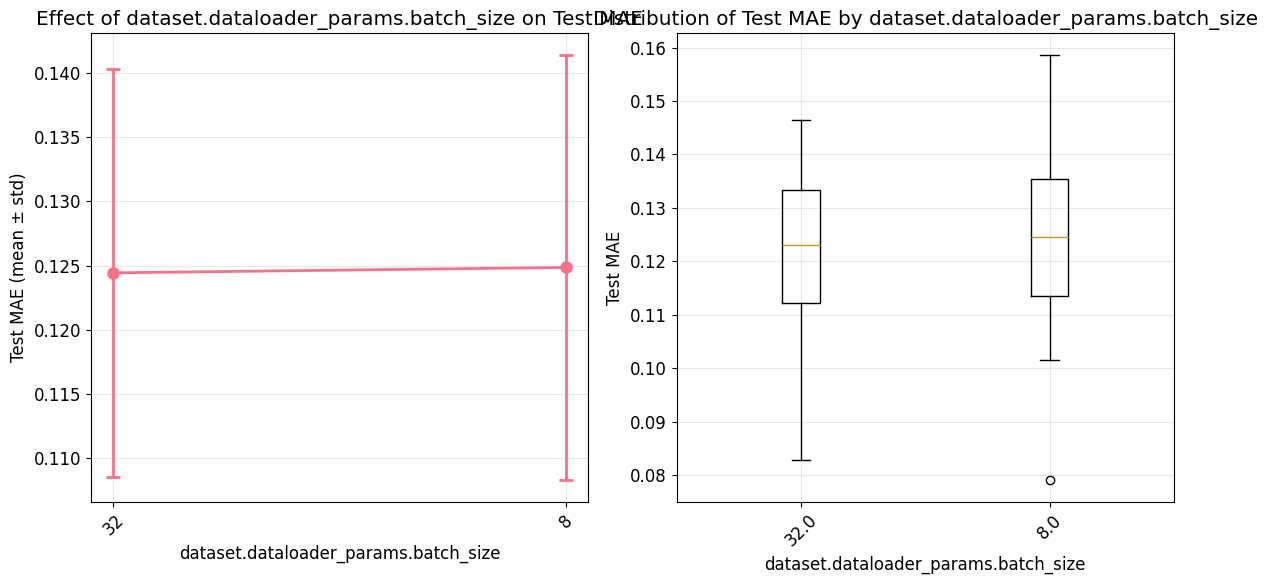


Summary for dataset.dataloader_params.batch_size:
 dataset.dataloader_params.batch_size  n_runs   mean    std    min    max  median
                                   32    4511 0.1244 0.0159 0.0766 0.1476  0.1283
                                    8    6333 0.1249 0.0166 0.0706 0.1453  0.1312

Analyzing: dataset.loader.parameters.adj_thresh


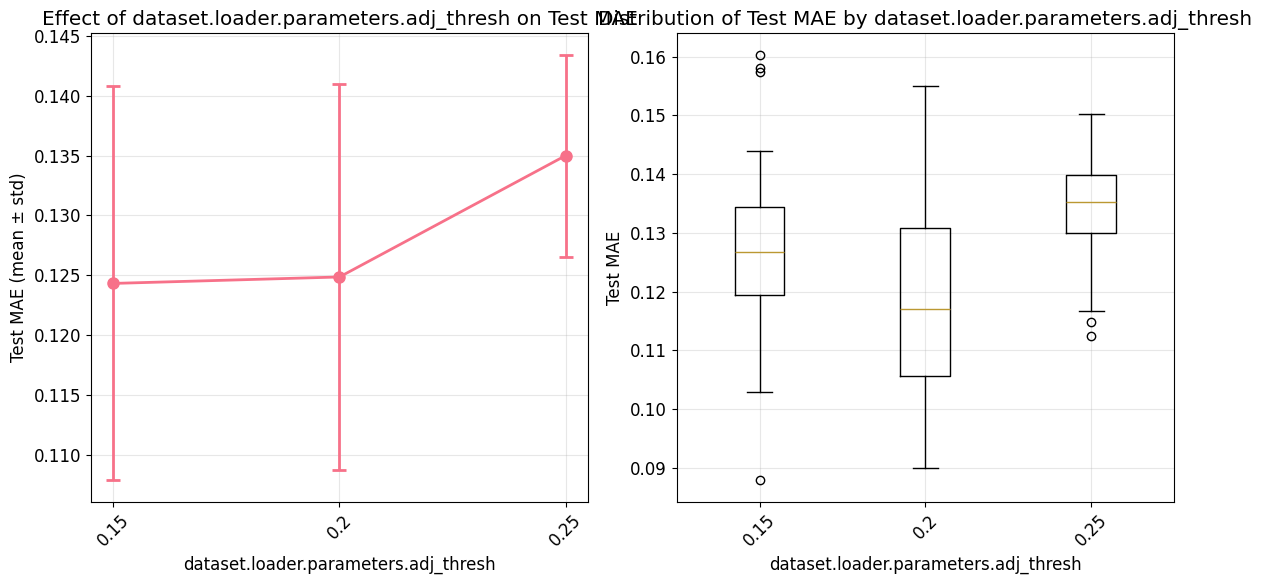


Summary for dataset.loader.parameters.adj_thresh:
 dataset.loader.parameters.adj_thresh  n_runs   mean    std    min    max  median
                               0.1500    7125 0.1243 0.0164 0.0762 0.1476  0.1298
                               0.2000    3539 0.1249 0.0161 0.0706 0.1472  0.1302
                               0.2500     180 0.1350 0.0084 0.1102 0.1445  0.1313

Analyzing: model.backbone.act


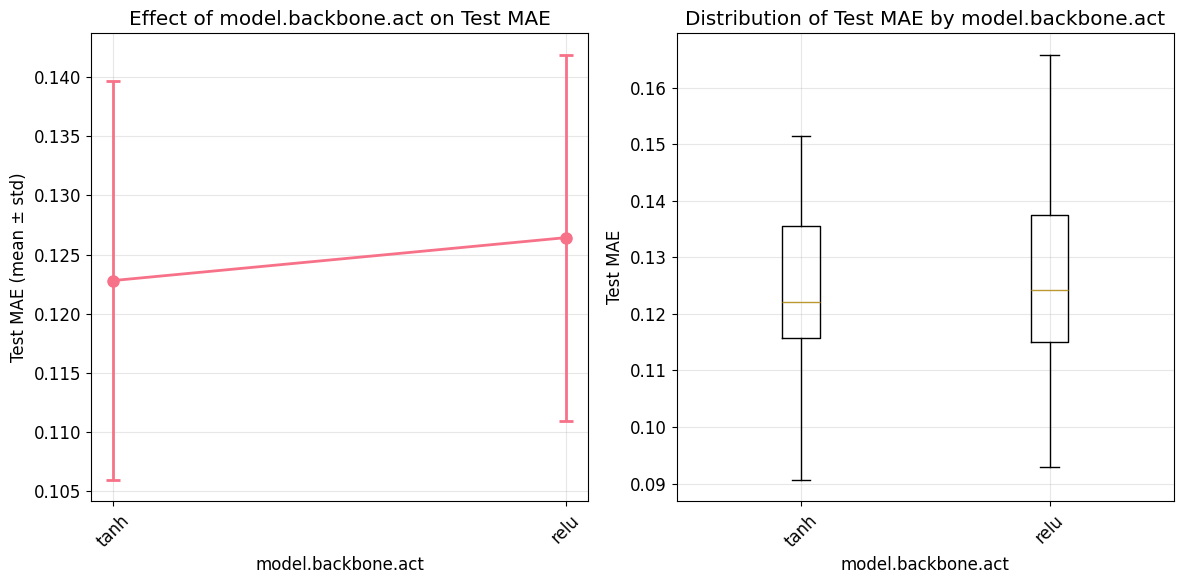


Summary for model.backbone.act:
model.backbone.act  n_runs   mean    std    min    max  median
              tanh    5213 0.1228 0.0169 0.0706 0.1476  0.1267
              relu    5631 0.1264 0.0155 0.0766 0.1475  0.1312

Analyzing: model.backbone.dropout


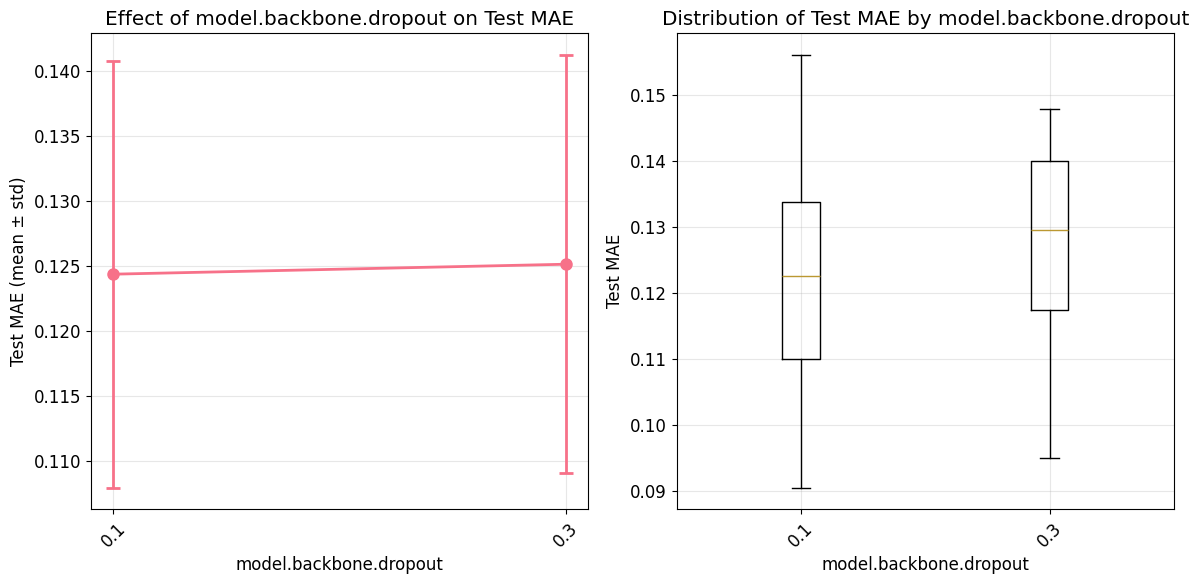


Summary for model.backbone.dropout:
 model.backbone.dropout  n_runs   mean    std    min    max  median
                 0.1000    5962 0.1243 0.0164 0.0716 0.1476  0.1299
                 0.3000    4882 0.1251 0.0161 0.0706 0.1475  0.1305

Analyzing: model.backbone.hidden_channels


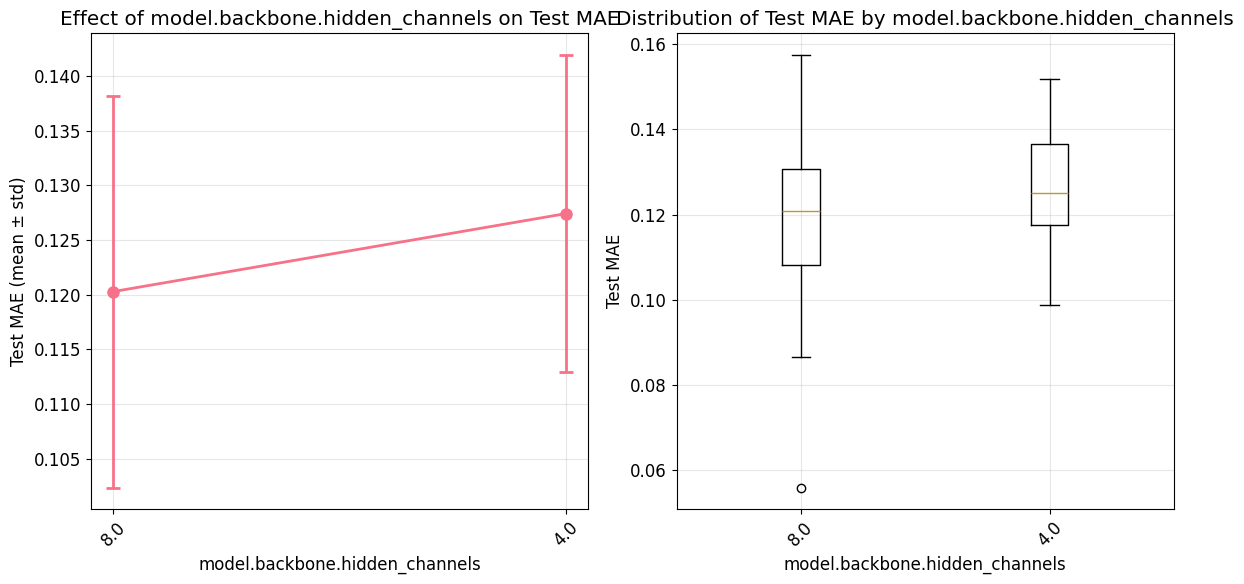


Summary for model.backbone.hidden_channels:
 model.backbone.hidden_channels  n_runs   mean    std    min    max  median
                         8.0000    4163 0.1203 0.0179 0.0766 0.1476  0.1236
                         4.0000    6681 0.1274 0.0145 0.0706 0.1472  0.1312

Analyzing: model.backbone.in_channels


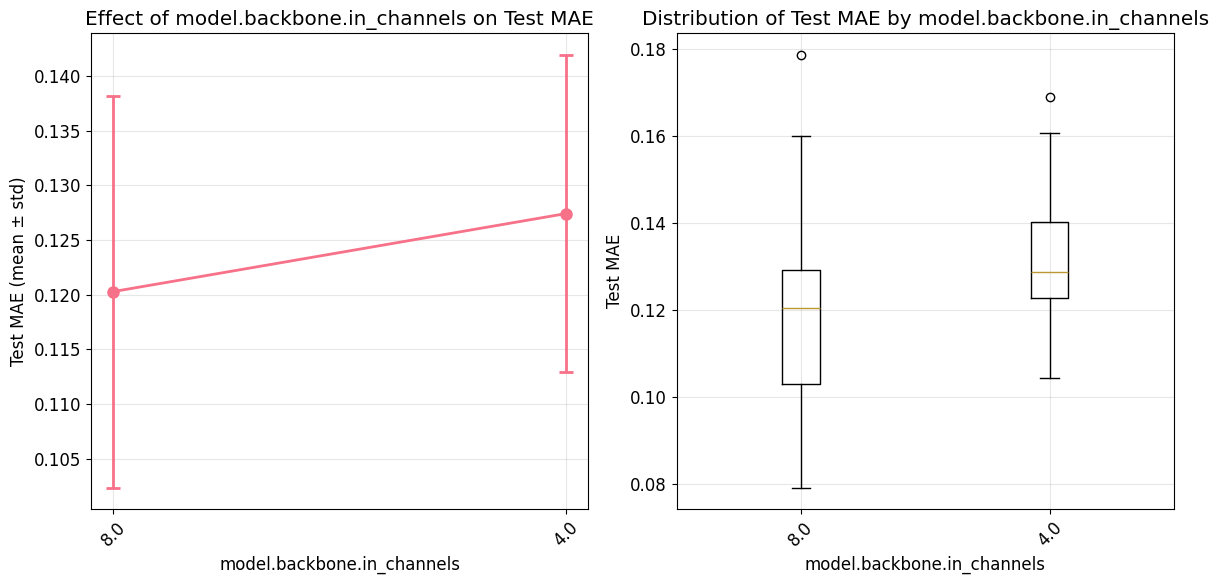


Summary for model.backbone.in_channels:
 model.backbone.in_channels  n_runs   mean    std    min    max  median
                     8.0000    4163 0.1203 0.0179 0.0766 0.1476  0.1236
                     4.0000    6681 0.1274 0.0145 0.0706 0.1472  0.1312

Analyzing: model.backbone_wrapper.out_channels


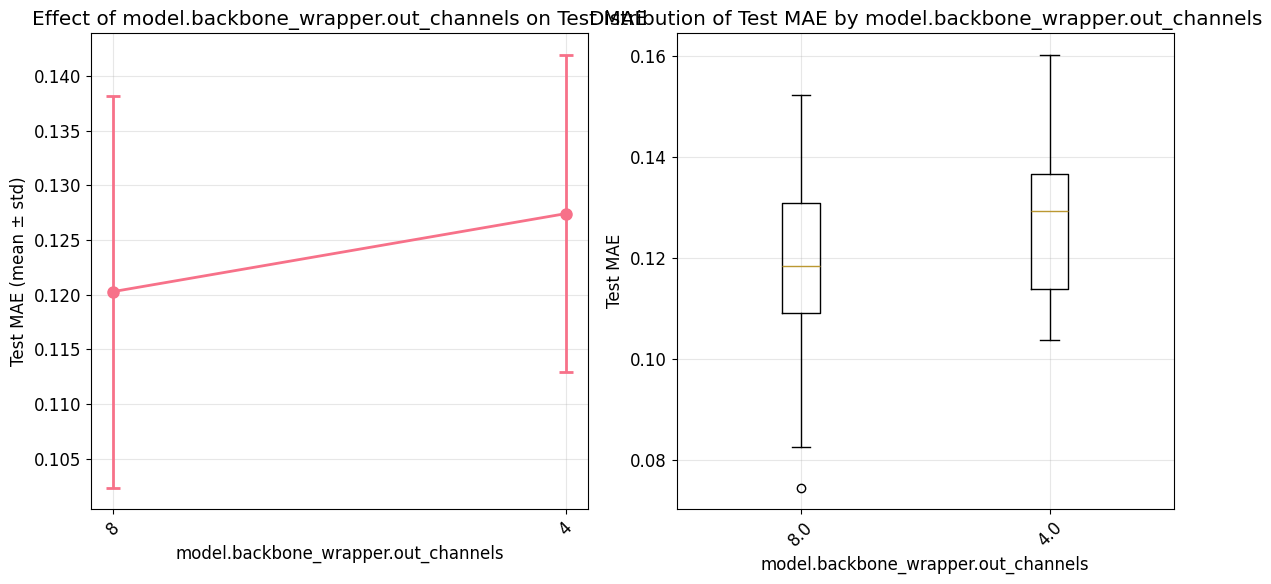


Summary for model.backbone_wrapper.out_channels:
 model.backbone_wrapper.out_channels  n_runs   mean    std    min    max  median
                                   8    4163 0.1203 0.0179 0.0766 0.1476  0.1236
                                   4    6681 0.1274 0.0145 0.0706 0.1472  0.1312

Analyzing: model.feature_encoder.out_channels


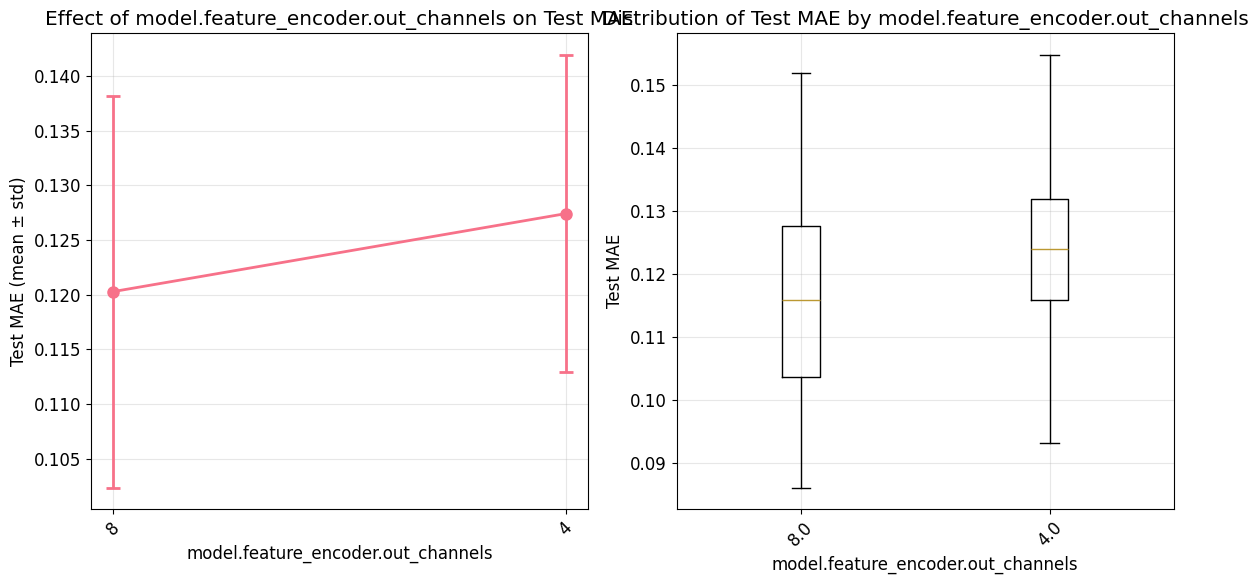


Summary for model.feature_encoder.out_channels:
 model.feature_encoder.out_channels  n_runs   mean    std    min    max  median
                                  8    4163 0.1203 0.0179 0.0766 0.1476  0.1236
                                  4    6681 0.1274 0.0145 0.0706 0.1472  0.1312

Analyzing: model.readout.fc_act


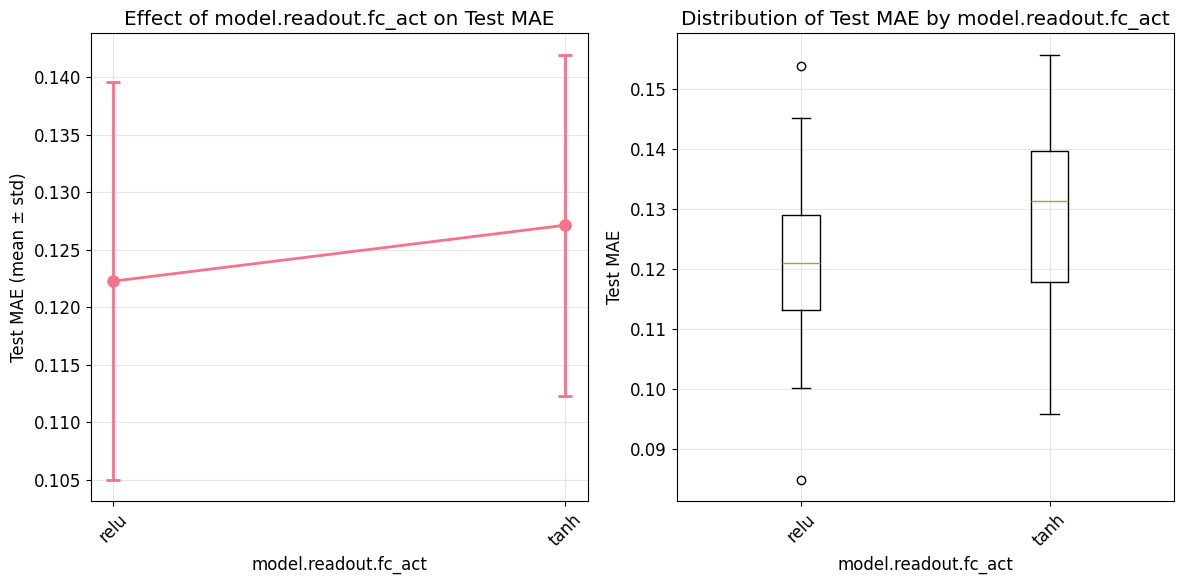


Summary for model.readout.fc_act:
model.readout.fc_act  n_runs   mean    std    min    max  median
                relu    5435 0.1223 0.0173 0.0756 0.1476  0.1272
                tanh    5409 0.1271 0.0148 0.0706 0.1453  0.1312

Analyzing: model.readout.fc_dim


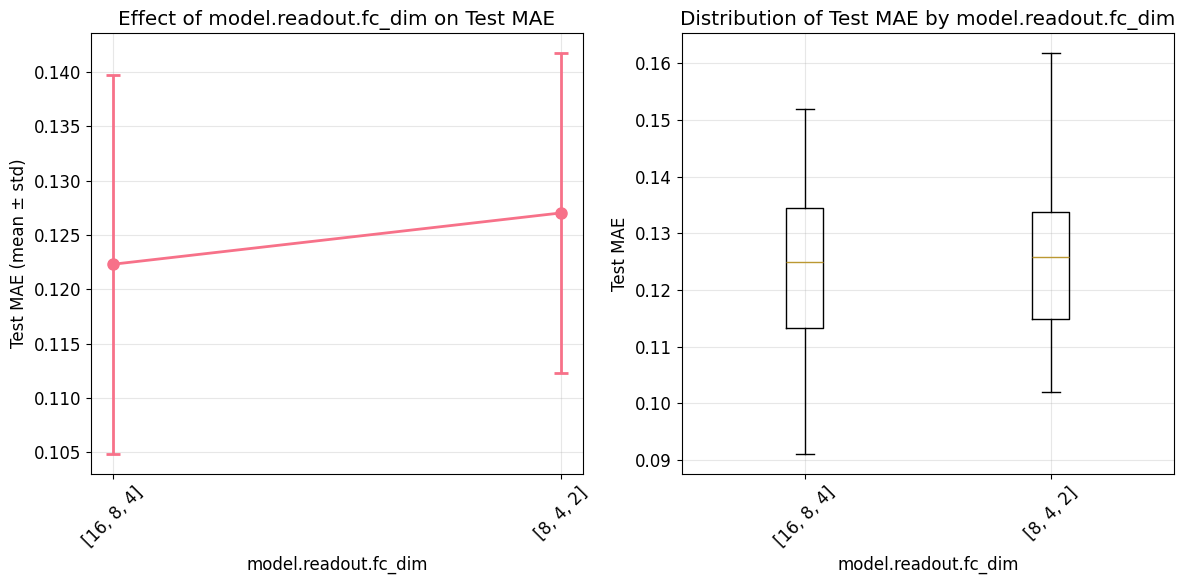


Summary for model.readout.fc_dim:
model.readout.fc_dim  n_runs   mean    std    min    max  median
          [16, 8, 4]    5392 0.1223 0.0174 0.0706 0.1454  0.1277
           [8, 4, 2]    5452 0.1270 0.0147 0.0766 0.1476  0.1312

Analyzing: model.readout.fc_input_dim


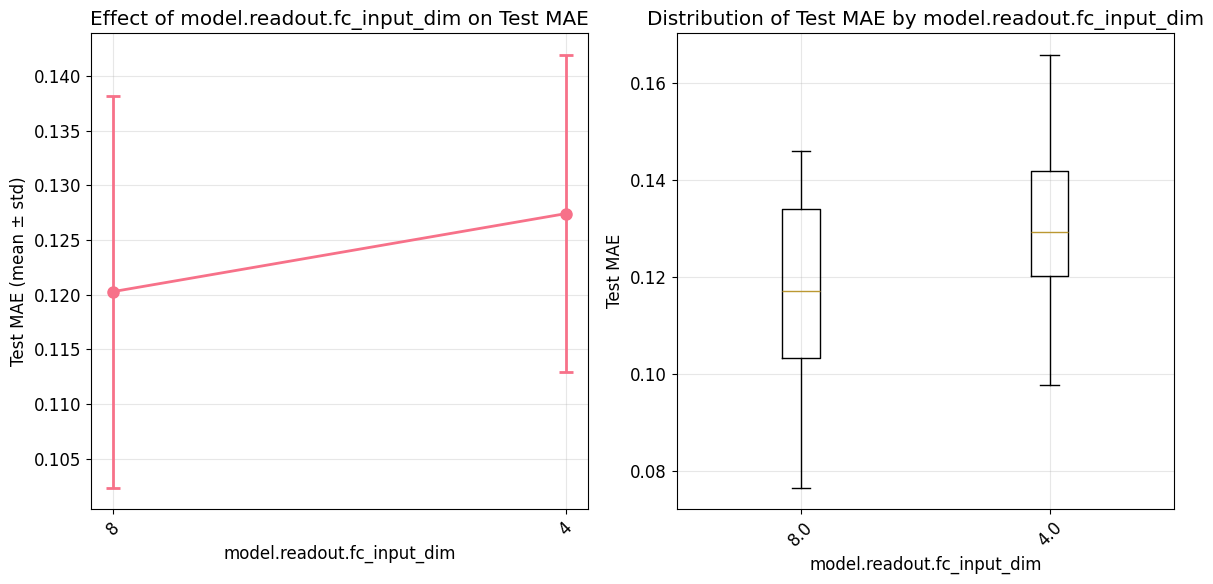


Summary for model.readout.fc_input_dim:
 model.readout.fc_input_dim  n_runs   mean    std    min    max  median
                          8    4163 0.1203 0.0179 0.0766 0.1476  0.1236
                          4    6681 0.1274 0.0145 0.0706 0.1472  0.1312

Analyzing: model.readout.feature_encoder_dim


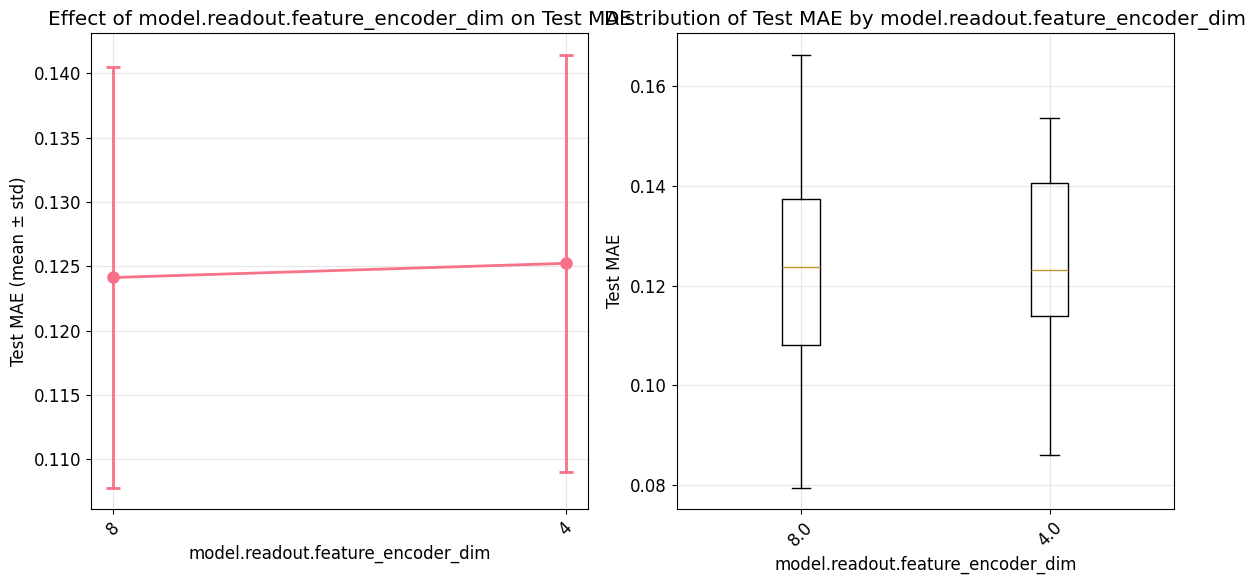


Summary for model.readout.feature_encoder_dim:
 model.readout.feature_encoder_dim  n_runs   mean    std    min    max  median
                                 8    5353 0.1241 0.0163 0.0706 0.1472  0.1294
                                 4    5491 0.1252 0.0162 0.0756 0.1476  0.1311

Analyzing: model.readout.graph_encoder_dim


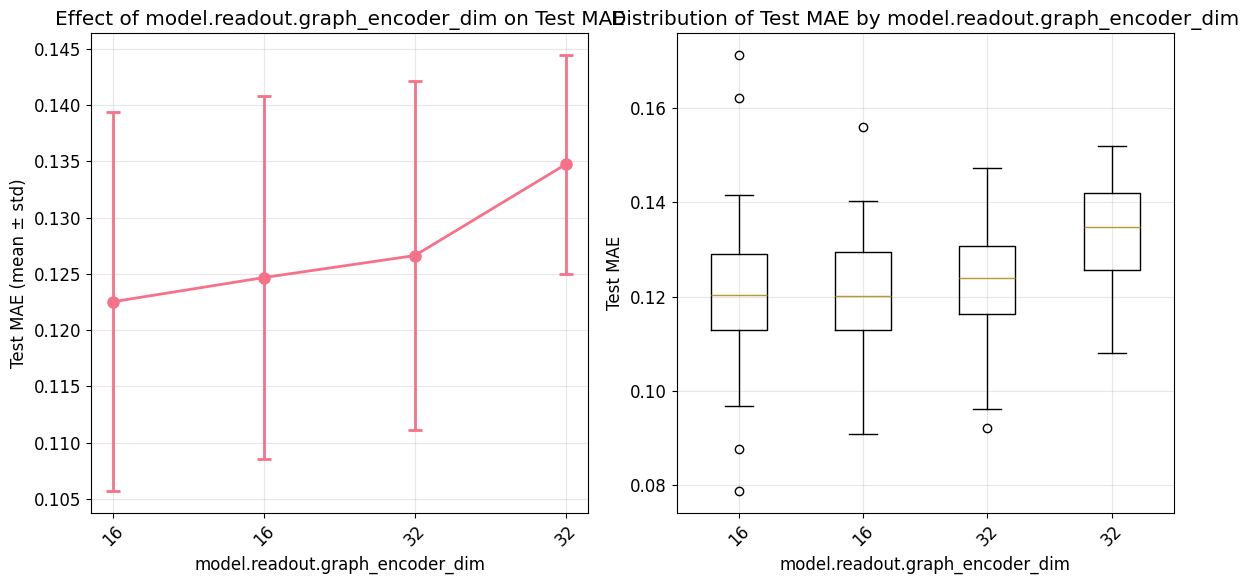


Summary for model.readout.graph_encoder_dim:
model.readout.graph_encoder_dim  n_runs   mean    std    min    max  median
                             16    5091 0.1225 0.0168 0.0706 0.1472  0.1267
                             16     475 0.1247 0.0161 0.0797 0.1446  0.1309
                             32    5180 0.1266 0.0155 0.0756 0.1476  0.1312
                             32      98 0.1347 0.0097 0.0914 0.1447  0.1342

Analyzing: model.readout.hidden_dim


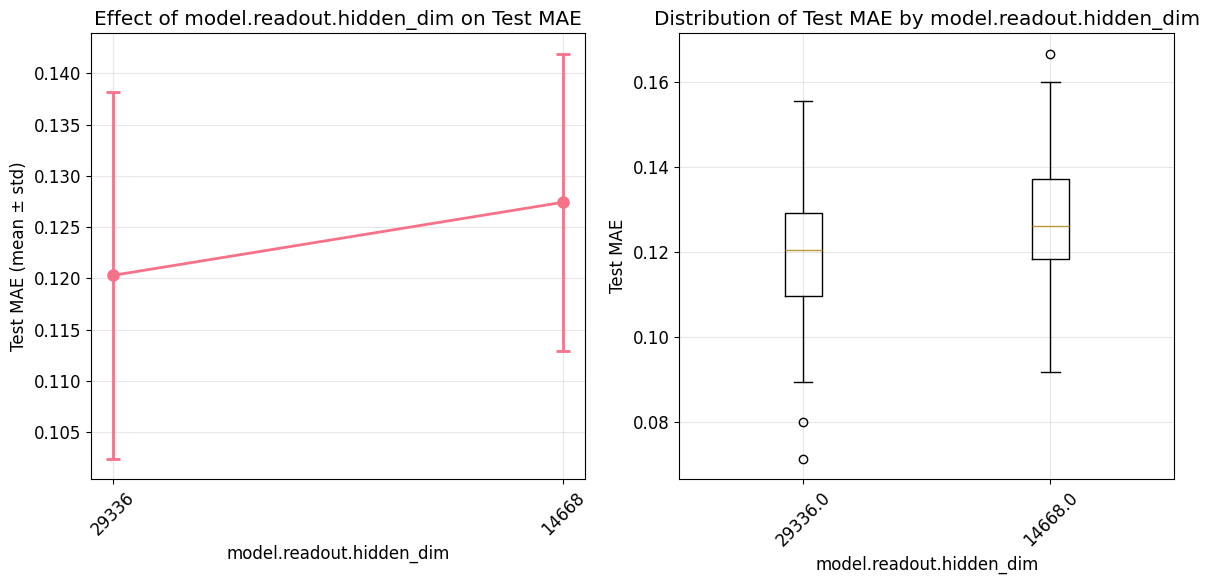


Summary for model.readout.hidden_dim:
 model.readout.hidden_dim  n_runs   mean    std    min    max  median
                    29336    4163 0.1203 0.0179 0.0766 0.1476  0.1236
                    14668    6681 0.1274 0.0145 0.0706 0.1472  0.1312

Analyzing: model.readout.in_channels


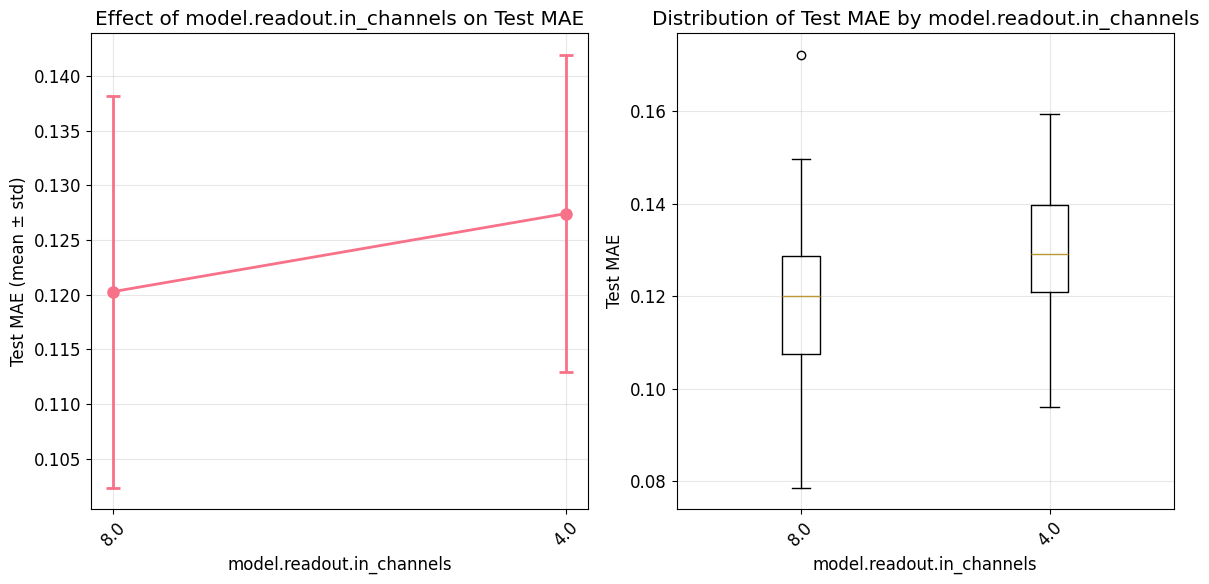


Summary for model.readout.in_channels:
 model.readout.in_channels  n_runs   mean    std    min    max  median
                    8.0000    4163 0.1203 0.0179 0.0766 0.1476  0.1236
                    4.0000    6681 0.1274 0.0145 0.0706 0.1472  0.1312

Analyzing: model/params/total


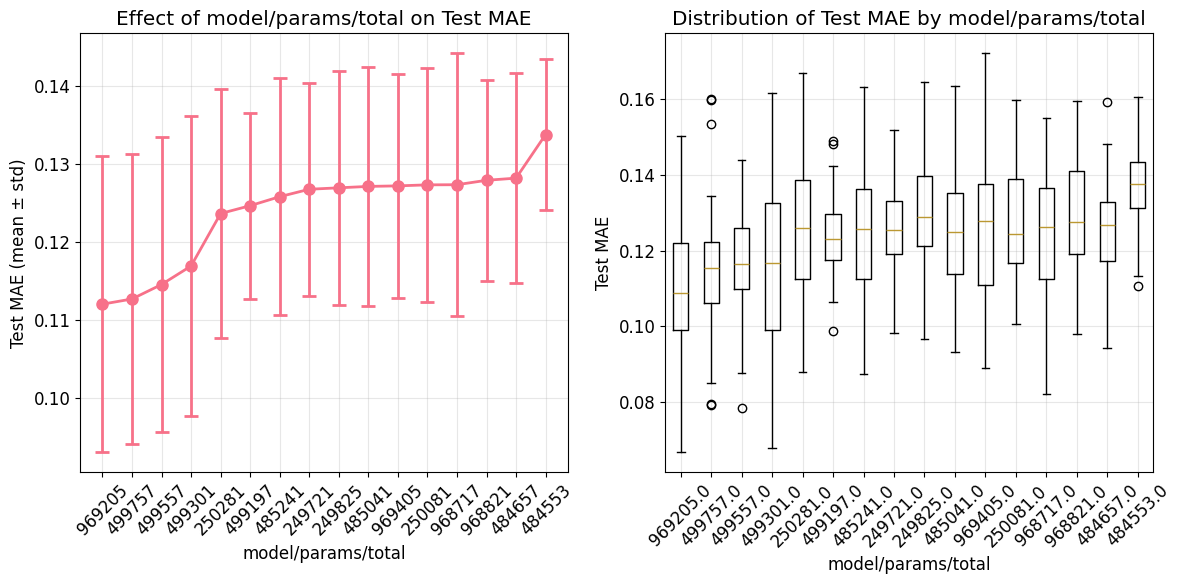


Summary for model/params/total:
 model/params/total  n_runs   mean    std    min    max  median
             969205     505 0.1120 0.0189 0.0778 0.1446  0.1072
             499757     528 0.1127 0.0186 0.0773 0.1450  0.1085
             499557     545 0.1146 0.0189 0.0798 0.1445  0.1133
             499301     538 0.1169 0.0192 0.0766 0.1448  0.1168
             250281     840 0.1236 0.0160 0.0706 0.1453  0.1275
             499197     546 0.1246 0.0119 0.0860 0.1444  0.1250
             485241     803 0.1258 0.0152 0.0777 0.1444  0.1297
             249721     862 0.1267 0.0136 0.0826 0.1446  0.1291
             249825     849 0.1269 0.0150 0.0799 0.1472  0.1310
             485041     824 0.1271 0.0153 0.0756 0.1447  0.1312
             969405     489 0.1272 0.0143 0.0850 0.1454  0.1312
             250081     858 0.1273 0.0150 0.0772 0.1447  0.1312
             968717     517 0.1273 0.0168 0.0794 0.1476  0.1340
             968821     495 0.1279 0.0129 0.0838 0.1443  0.1313
       

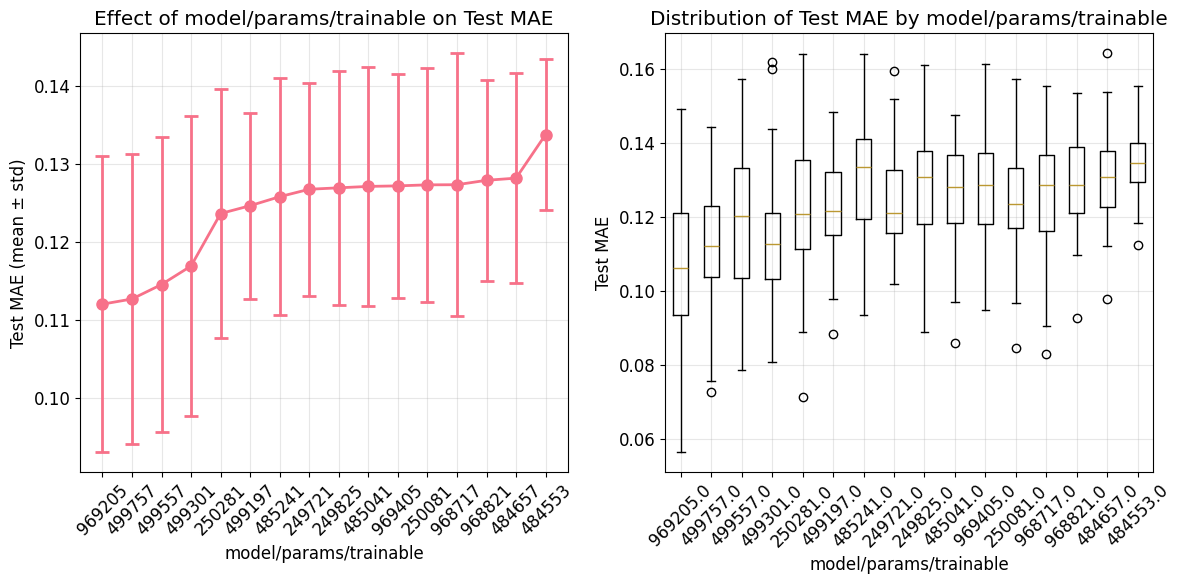


Summary for model/params/trainable:
 model/params/trainable  n_runs   mean    std    min    max  median
                 969205     505 0.1120 0.0189 0.0778 0.1446  0.1072
                 499757     528 0.1127 0.0186 0.0773 0.1450  0.1085
                 499557     545 0.1146 0.0189 0.0798 0.1445  0.1133
                 499301     538 0.1169 0.0192 0.0766 0.1448  0.1168
                 250281     840 0.1236 0.0160 0.0706 0.1453  0.1275
                 499197     546 0.1246 0.0119 0.0860 0.1444  0.1250
                 485241     803 0.1258 0.0152 0.0777 0.1444  0.1297
                 249721     862 0.1267 0.0136 0.0826 0.1446  0.1291
                 249825     849 0.1269 0.0150 0.0799 0.1472  0.1310
                 485041     824 0.1271 0.0153 0.0756 0.1447  0.1312
                 969405     489 0.1272 0.0143 0.0850 0.1454  0.1312
                 250081     858 0.1273 0.0150 0.0772 0.1447  0.1312
                 968717     517 0.1273 0.0168 0.0794 0.1476  0.1340
           

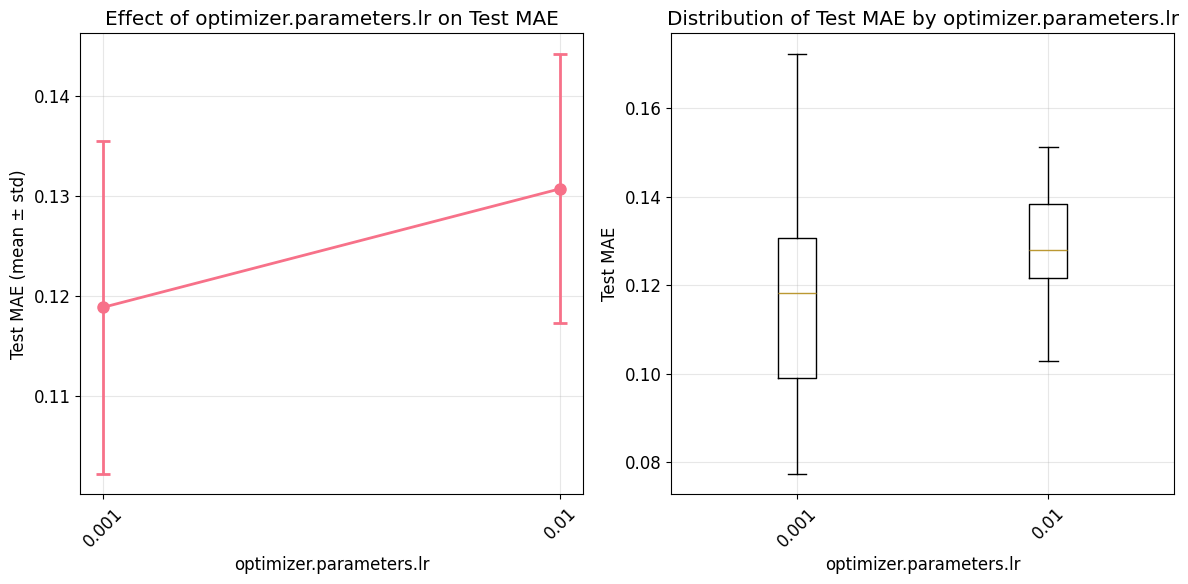


Summary for optimizer.parameters.lr:
 optimizer.parameters.lr  n_runs   mean    std    min    max  median
                  0.0010    5546 0.1189 0.0166 0.0706 0.1476  0.1208
                  0.0100    5298 0.1308 0.0135 0.0766 0.1447  0.1340

Analyzing: optimizer.parameters.weight_decay


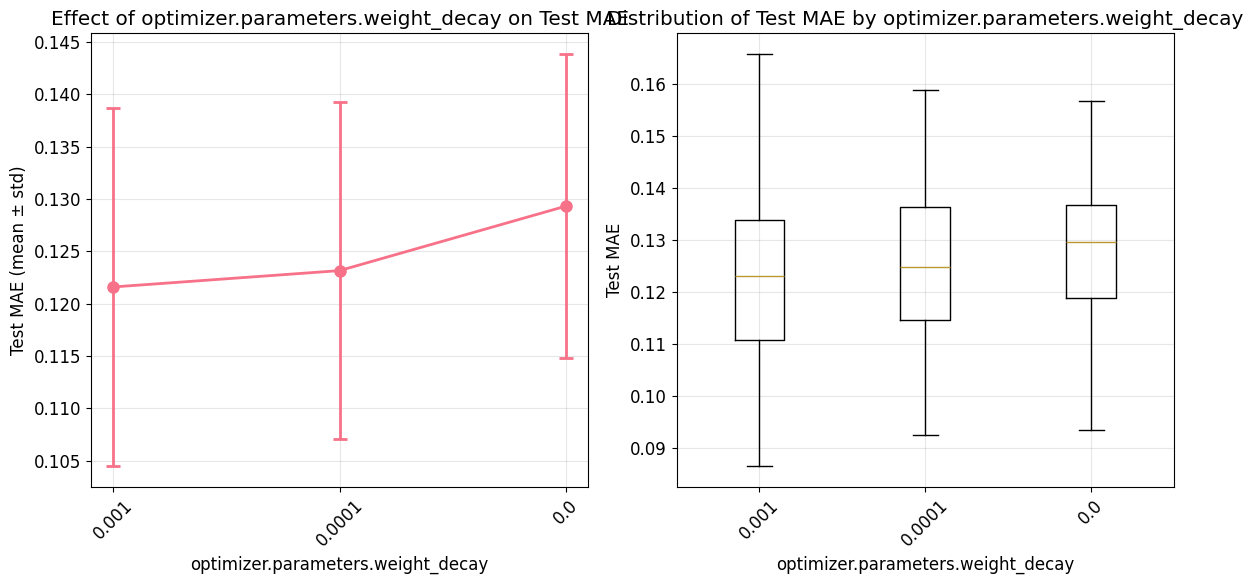


Summary for optimizer.parameters.weight_decay:
 optimizer.parameters.weight_decay  n_runs   mean    std    min    max  median
                            0.0010    3616 0.1216 0.0171 0.0706 0.1454  0.1250
                            0.0001    3609 0.1232 0.0161 0.0716 0.1476  0.1268
                            0.0000    3619 0.1293 0.0145 0.0758 0.1476  0.1340

Analyzing: trainer.devices


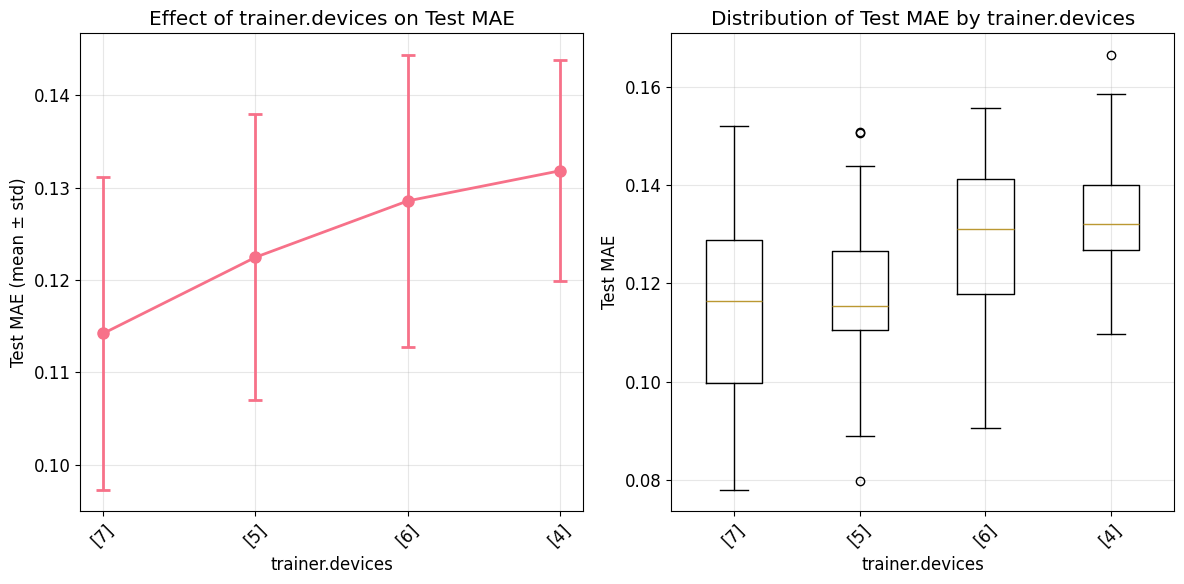


Summary for trainer.devices:
trainer.devices  n_runs   mean    std    min    max  median
            [7]    2398 0.1142 0.0169 0.0769 0.1476  0.1136
            [5]    3148 0.1225 0.0155 0.0706 0.1472  0.1247
            [6]    1765 0.1286 0.0158 0.0766 0.1446  0.1340
            [4]    3533 0.1318 0.0120 0.0804 0.1447  0.1340

Individual plots completed!


In [8]:
# Create individual plots for each hyperparameter
print("Creating individual hyperparameter effect plots...")
for hyperparam_name, summary_df in hyperparam_results.items():
    print(f"\n{'='*60}")
    print(f"Analyzing: {hyperparam_name}")
    print(f"{'='*60}")
    
    plot_hyperparameter_effect(summary_df, hyperparam_name, 'Test MAE')

print(f"\n{'='*60}")
print("Individual plots completed!")
print(f"{'='*60}")


Creating comparison plot for all hyperparameters...


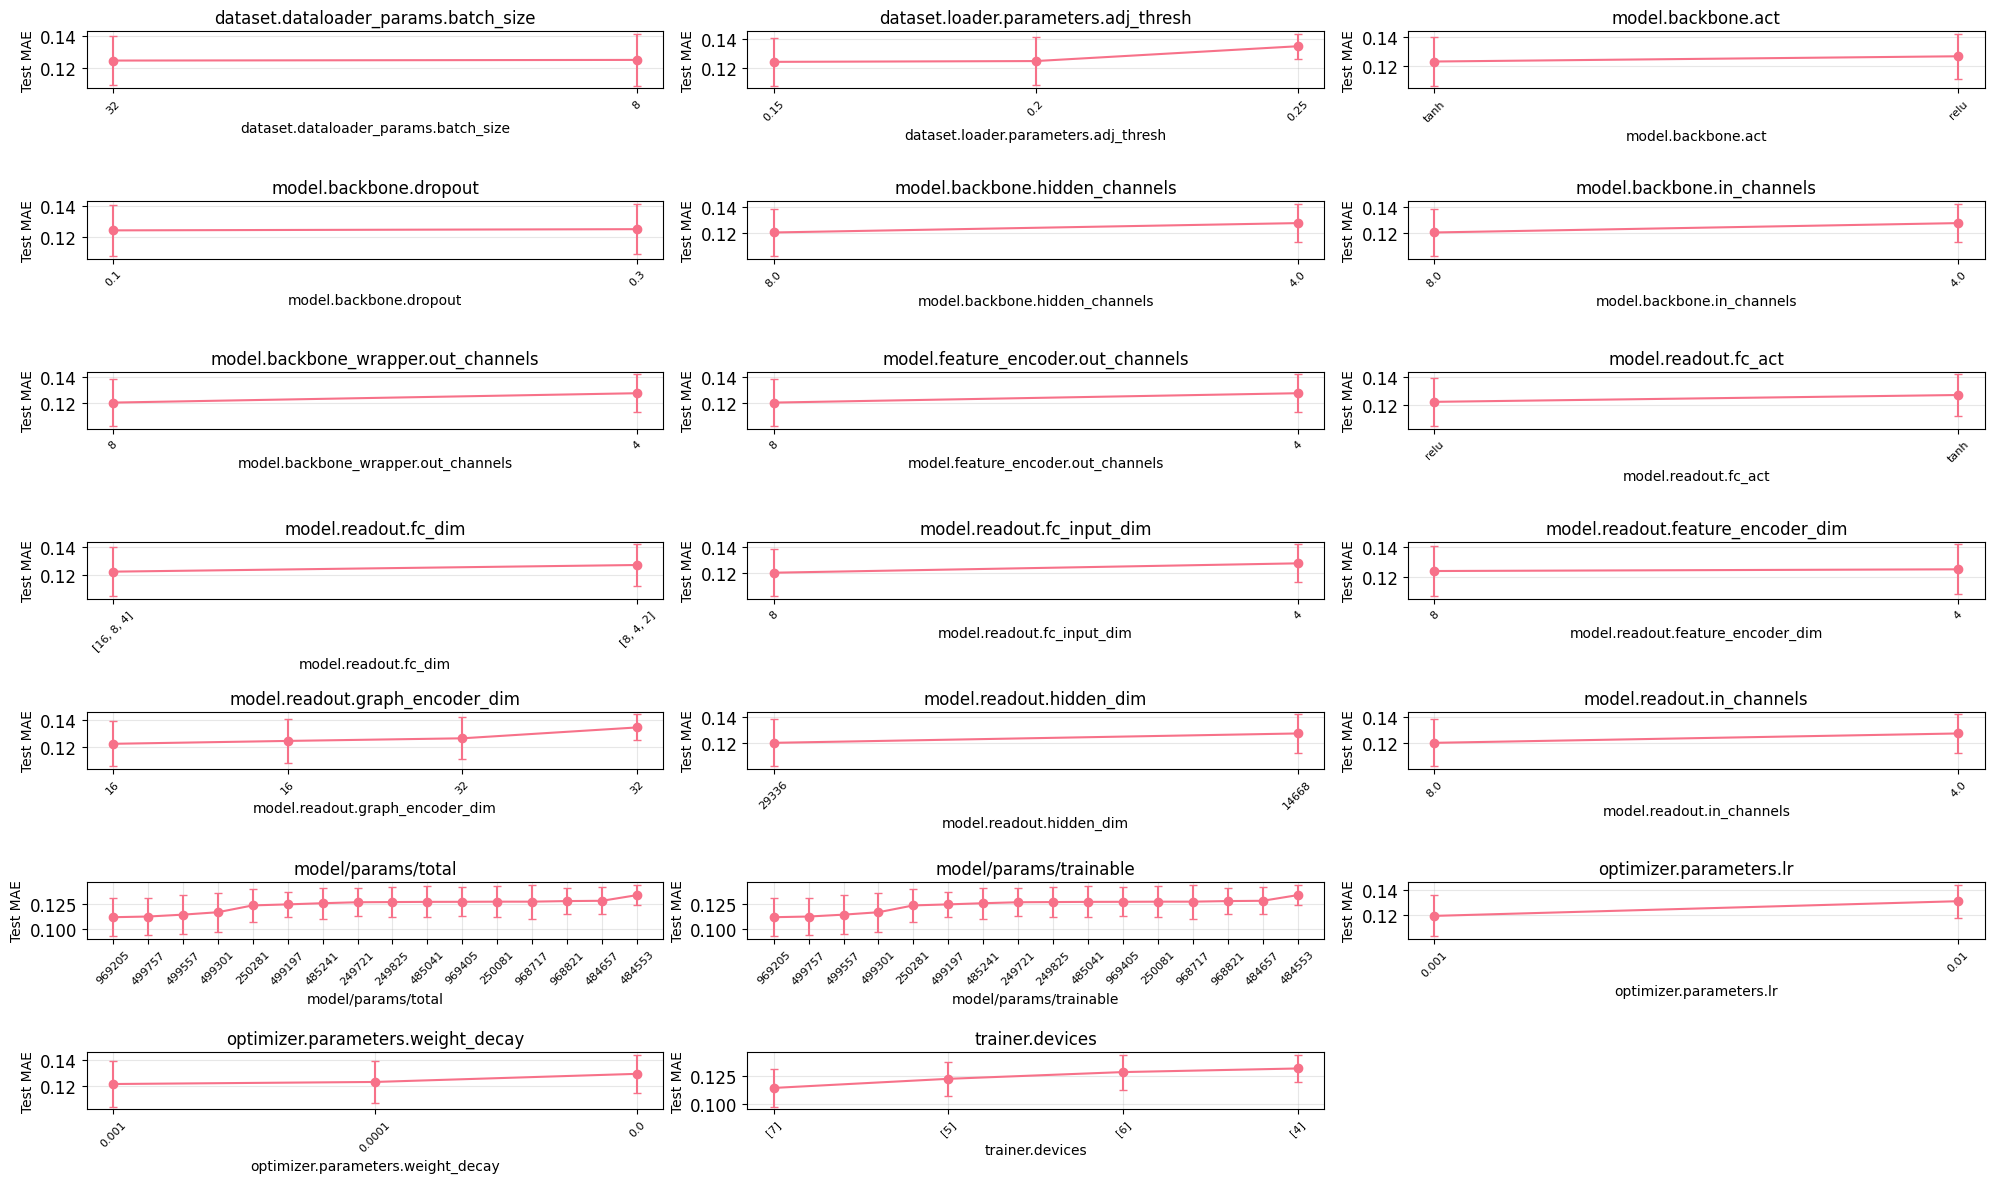

Comparison plot completed!


In [9]:
# Create comparison plot showing all hyperparameters
print("Creating comparison plot for all hyperparameters...")
plot_hyperparameter_comparison(hyperparam_results, 'Test MAE', figsize=(20, 12))
print("Comparison plot completed!")


## Summary Statistics

Generate summary statistics and identify the most important hyperparameters.


Calculating hyperparameter importance...

Hyperparameter Importance Ranking:
                      hyperparameter  n_values mean_range mean_std coefficient_of_variation cohens_d best_value best_performance worst_value worst_performance
                  model/params/total        16     0.0217   0.0063                   0.0510   1.3982     969205           0.1120      484553            0.1337
              model/params/trainable        16     0.0217   0.0063                   0.0510   1.3982     969205           0.1120      484553            0.1337
                     trainer.devices         4     0.0176   0.0078                   0.0624   1.1634        [7]           0.1142         [4]            0.1318
     model.readout.graph_encoder_dim         4     0.0122   0.0053                   0.0419   0.8234         16           0.1225          32            0.1347
             optimizer.parameters.lr         2     0.0119   0.0084                   0.0672   0.7839      0.001           0.1189

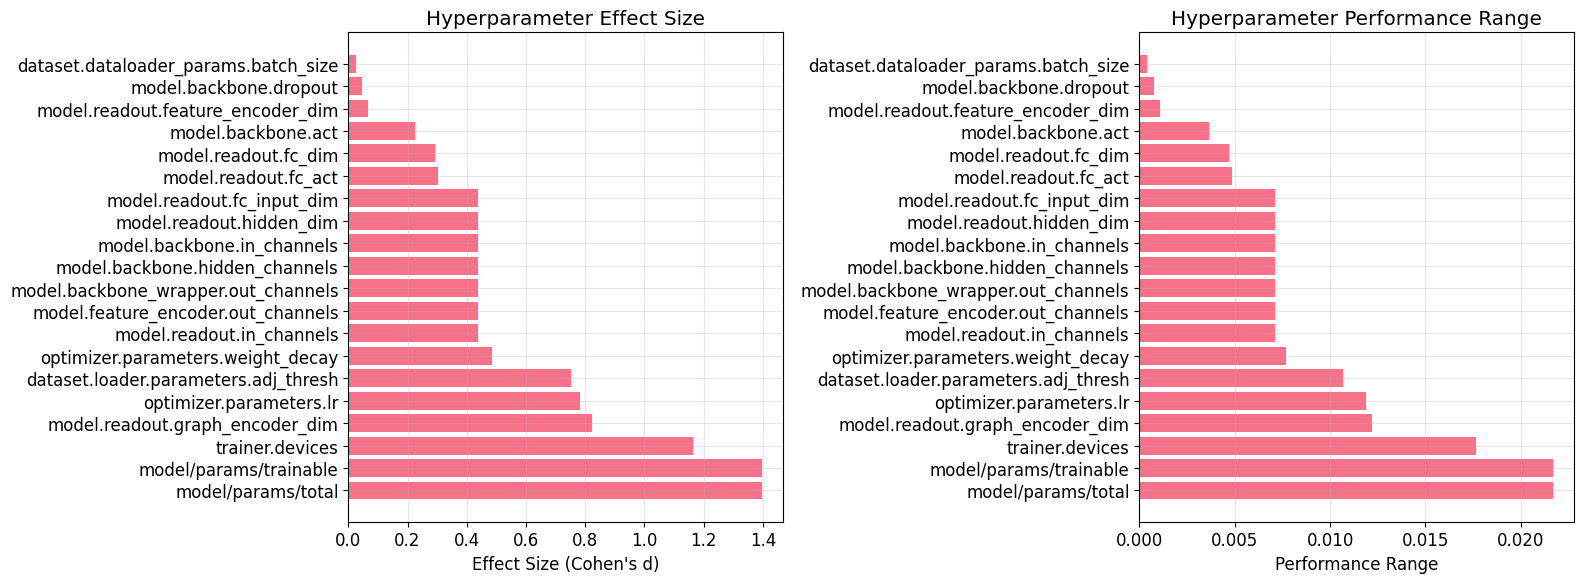


ANALYSIS SUMMARY
Total hyperparameters analyzed: 20
Total dataset-model combinations: 1
Total runs analyzed: 10844

Most important hyperparameters:
  16. model/params/total (effect size: 1.398)
     Best: 969205 (0.1120)
     Worst: 484553 (0.1337)
     Range: 0.0217

  17. model/params/trainable (effect size: 1.398)
     Best: 969205 (0.1120)
     Worst: 484553 (0.1337)
     Range: 0.0217

  20. trainer.devices (effect size: 1.163)
     Best: [7] (0.1142)
     Worst: [4] (0.1318)
     Range: 0.0176



In [10]:
def calculate_hyperparameter_importance(hyperparam_results):
    """
    Calculate the importance of each hyperparameter based on performance variance.
    
    Parameters:
    -----------
    hyperparam_results : dict
        Dictionary containing summary results for each hyperparameter
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with hyperparameter importance metrics
    """
    importance_data = []
    
    for hyperparam_name, summary_df in hyperparam_results.items():
        if len(summary_df) < 2:
            continue
            
        # Calculate various importance metrics
        mean_range = summary_df['mean'].max() - summary_df['mean'].min()
        mean_std = summary_df['mean'].std()
        coefficient_of_variation = mean_std / summary_df['mean'].mean()
        
        # Calculate effect size (Cohen's d)
        best_mean = summary_df['mean'].min()
        worst_mean = summary_df['mean'].max()
        pooled_std = np.sqrt((summary_df['std']**2).mean())
        cohens_d = (worst_mean - best_mean) / pooled_std if pooled_std > 0 else 0
        
        # Get best and worst values safely
        best_idx = summary_df['mean'].idxmin()
        worst_idx = summary_df['mean'].idxmax()
        
        best_value = summary_df.loc[best_idx, hyperparam_name]
        worst_value = summary_df.loc[worst_idx, hyperparam_name]
        
        importance_data.append({
            'hyperparameter': hyperparam_name,
            'n_values': len(summary_df),
            'mean_range': mean_range,
            'mean_std': mean_std,
            'coefficient_of_variation': coefficient_of_variation,
            'cohens_d': cohens_d,
            'best_value': best_value,
            'best_performance': best_mean,
            'worst_value': worst_value,
            'worst_performance': worst_mean
        })
    
    importance_df = pd.DataFrame(importance_data)
    
    # Sort by effect size (Cohen's d)
    importance_df = importance_df.sort_values('cohens_d', ascending=False)
    
    return importance_df

# Calculate hyperparameter importance
print("Calculating hyperparameter importance...")
importance_df = calculate_hyperparameter_importance(hyperparam_results)

print(f"\nHyperparameter Importance Ranking:")
print(f"{'='*80}")
if len(importance_df) > 0:
    # Fix the float_format issue by using a lambda function
    print(importance_df.to_string(index=False, formatters={
        'mean_range': lambda x: f'{x:.4f}',
        'mean_std': lambda x: f'{x:.4f}',
        'coefficient_of_variation': lambda x: f'{x:.4f}',
        'cohens_d': lambda x: f'{x:.4f}',
        'best_performance': lambda x: f'{x:.4f}',
        'worst_performance': lambda x: f'{x:.4f}'
    }))
else:
    print("No hyperparameters found with sufficient data for importance calculation.")

# Create a visualization of hyperparameter importance
if len(importance_df) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Effect size (Cohen's d)
    ax1.barh(range(len(importance_df)), importance_df['cohens_d'])
    ax1.set_yticks(range(len(importance_df)))
    ax1.set_yticklabels(importance_df['hyperparameter'])
    ax1.set_xlabel("Effect Size (Cohen's d)")
    ax1.set_title('Hyperparameter Effect Size')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Performance range
    ax2.barh(range(len(importance_df)), importance_df['mean_range'])
    ax2.set_yticks(range(len(importance_df)))
    ax2.set_yticklabels(importance_df['hyperparameter'])
    ax2.set_xlabel('Performance Range')
    ax2.set_title('Hyperparameter Performance Range')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print(f"\n{'='*80}")
print("ANALYSIS SUMMARY")
print(f"{'='*80}")
print(f"Total hyperparameters analyzed: {len(hyperparam_results)}")
print(f"Total dataset-model combinations: {len(df_processed.groupby(['dataset', 'model']).size())}")
print(f"Total runs analyzed: {len(df_processed)}")

if len(importance_df) > 0:
    print(f"\nMost important hyperparameters:")
    for i, row in importance_df.head(3).iterrows():
        print(f"  {i+1}. {row['hyperparameter']} (effect size: {row['cohens_d']:.3f})")
        print(f"     Best: {row['best_value']} ({row['best_performance']:.4f})")
        print(f"     Worst: {row['worst_value']} ({row['worst_performance']:.4f})")
        print(f"     Range: {row['mean_range']:.4f}")
        print()
else:
    print("\nNo hyperparameters found with sufficient data for importance ranking.")


## Export Results

Save the analysis results to files for further use.


In [11]:
# Export results to CSV files
print("Exporting results...")

# Export hyperparameter importance
if len(importance_df) > 0:
    importance_filename = f"hyperparameter_importance_{wandb_project}_{wandb_username}.csv"
    importance_df.to_csv(importance_filename, index=False)
    print(f"Hyperparameter importance saved to: {importance_filename}")

# Export detailed results for each hyperparameter
for hyperparam_name, summary_df in hyperparam_results.items():
    filename = f"hyperparameter_effect_{hyperparam_name}_{wandb_project}_{wandb_username}.csv"
    summary_df.to_csv(filename, index=False)
    print(f"{hyperparam_name} effect analysis saved to: {filename}")

print("\nAll results exported successfully!")
print(f"\nFiles saved in: {os.getcwd()}")


Exporting results...
Hyperparameter importance saved to: hyperparameter_importance_Proteo_new_variable_stratified_filtered_lcornelis.csv
dataset.dataloader_params.batch_size effect analysis saved to: hyperparameter_effect_dataset.dataloader_params.batch_size_Proteo_new_variable_stratified_filtered_lcornelis.csv
dataset.loader.parameters.adj_thresh effect analysis saved to: hyperparameter_effect_dataset.loader.parameters.adj_thresh_Proteo_new_variable_stratified_filtered_lcornelis.csv
model.backbone.act effect analysis saved to: hyperparameter_effect_model.backbone.act_Proteo_new_variable_stratified_filtered_lcornelis.csv
model.backbone.dropout effect analysis saved to: hyperparameter_effect_model.backbone.dropout_Proteo_new_variable_stratified_filtered_lcornelis.csv
model.backbone.hidden_channels effect analysis saved to: hyperparameter_effect_model.backbone.hidden_channels_Proteo_new_variable_stratified_filtered_lcornelis.csv
model.backbone.in_channels effect analysis saved to: hyperp

OSError: Cannot save file into a non-existent directory: 'hyperparameter_effect_model/params'

## Conclusion

This analysis provides insights into:

1. **Overall hyperparameter effects**: How each hyperparameter affects model performance across all runs
2. **Hyperparameter importance ranking**: Which hyperparameters have the largest impact on performance
3. **Optimal hyperparameter values**: The best values for each hyperparameter based on the analysis
4. **Performance range and variability**: The spread of performance for each hyperparameter

### Key Findings:
- The most important hyperparameters (highest effect size)
- The optimal values for each hyperparameter
- The performance range and variability for each hyperparameter

### Next Steps:
- Use the identified optimal hyperparameter values for future experiments
- Focus hyperparameter tuning on the most important parameters
- Consider the performance variability when selecting hyperparameter values


In [ ]:
# Debug cell - run this if you encounter errors
print("=== DEBUG INFORMATION ===")
print(f"Data shape: {df_processed.shape}")
print(f"Columns: {list(df_processed.columns)}")
print(f"Hyperparameter columns: {hyperparam_cols}")
print(f"Number of hyperparameter results: {len(hyperparam_results)}")

# Check for common issues
print("\n=== CHECKING FOR COMMON ISSUES ===")

# Check if test_mae column exists and has data
if 'test_mae' in df_processed.columns:
    nan_count = df_processed['test_mae'].isna().sum()
    print(f"test_mae column: {nan_count} NaN values out of {len(df_processed)} total")
    if nan_count == len(df_processed):
        print("ERROR: All test_mae values are NaN!")
    else:
        print(f"test_mae range: {df_processed['test_mae'].min():.4f} to {df_processed['test_mae'].max():.4f}")
else:
    print("ERROR: test_mae column not found!")

# Check hyperparameter results
if len(hyperparam_results) == 0:
    print("ERROR: No hyperparameter results found!")
    print("This could be due to:")
    print("1. All hyperparameters having only one unique value")
    print("2. Insufficient runs per hyperparameter value")
    print("3. Missing or invalid data")
else:
    print(f"Found {len(hyperparam_results)} hyperparameters with results")
    for name, result in list(hyperparam_results.items())[:3]:  # Show first 3
        print(f"  {name}: {len(result)} values")

# Check importance calculation
if 'importance_df' in locals():
    print(f"\nImportance calculation: {len(importance_df)} hyperparameters ranked")
else:
    print("\nImportance calculation not yet run")

print("=== END DEBUG INFORMATION ===")
